# Bloque II — Parte 2 (Corregido y listo para entregar)

Pipeline completo con imputación, modelos y conclusiones.

In [29]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

%matplotlib inline

In [30]:
DATA_DIR = Path(".")
df = pd.read_csv(DATA_DIR / "ventas_mayo_2026.csv", parse_dates=["fecha"])

df["canal"] = df["canal"].fillna("desconocido")
df["precio_unitario"] = df["precio_unitario"].fillna(df["precio_unitario"].median())
df["dia_semana"] = df["fecha"].dt.dayofweek

df.head()

,fecha,cliente_id,categoria,region,canal,unidades,precio_unitario,descuento,antiguedad_cliente_meses,importe,dia_semana
0,2025-01-01,C1000,Hogar,Madrid,Online,8,99.920,0.07,63,836.25,2
1,2025-01-02,C1001,Servicios,Madrid,Distribuidor,5,192.950,0.10,52,956.72,3
2,2025-01-03,C1002,Moda,Madrid,Online,7,39.770,0.05,26,357.65,4
3,2025-01-04,C1003,Alimentación,Valencia,Online,9,25.170,0.06,53,301.52,5
4,2025-01-05,C1004,Tecnología,Castilla-La Mancha,Distribuidor,8,118.305,0.09,29,2101.55,6


In [31]:
X = df[["region","canal","unidades","precio_unitario","descuento","dia_semana"]]
y = df["importe"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [32]:
num_cols = ["unidades","precio_unitario","descuento","dia_semana"]
cat_cols = ["region","canal"]

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

pre = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

In [33]:
lin_model = Pipeline([
    ("pre", pre),
    ("model", LinearRegression())
])

rf_model = Pipeline([
    ("pre", pre),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        random_state=42
    ))
])

In [34]:
lin_model.fit(X_train, y_train)
pred_lin = lin_model.predict(X_test)

rf_model.fit(X_train, y_train)
pred_rf = rf_model.predict(X_test)

In [35]:
metrics = pd.DataFrame({
    "modelo": ["LinearRegression","RandomForest"],
    "MAE": [
        mean_absolute_error(y_test, pred_lin),
        mean_absolute_error(y_test, pred_rf)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, pred_lin)),
        np.sqrt(mean_squared_error(y_test, pred_rf))
    ],
    "R2": [
        r2_score(y_test, pred_lin),
        r2_score(y_test, pred_rf)
    ]
})

metrics.round(3)

,modelo,MAE,RMSE,R2
0,LinearRegression,213.864,288.660,0.908
1,RandomForest,142.626,186.457,0.961


In [36]:
errores = pd.DataFrame({
    "real": y_test,
    "predicho": pred_rf
})

errores["error"] = errores["real"] - errores["predicho"]

errores.sort_values("error", key=abs, ascending=False).head(10)

,real,predicho,error
334,4409.82,3714.057845,695.762155
15,455.61,1055.476233,-599.866233
354,2176.64,1638.511106,538.128894
25,377.50,837.529046,-460.029046
84,876.72,1273.206549,-396.486549
305,2065.63,1686.249994,379.380006
46,1326.69,1703.234018,-376.544018
244,3705.45,3351.423614,354.026386
331,176.26,490.821803,-314.561803
75,764.15,451.610331,312.539669


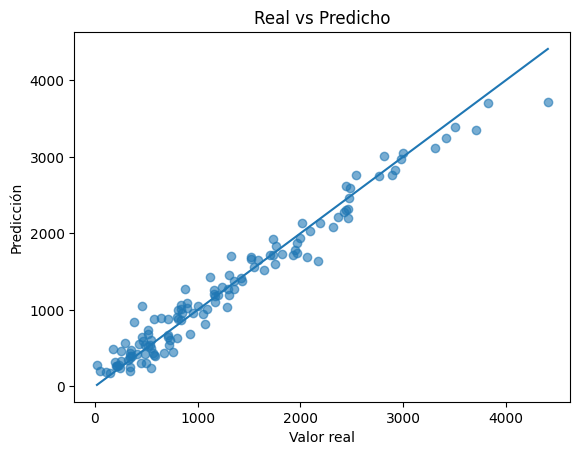

In [37]:
plt.figure()
plt.scatter(errores["real"], errores["predicho"], alpha=0.6)
plt.plot(
    [errores["real"].min(), errores["real"].max()],
    [errores["real"].min(), errores["real"].max()]
)
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("Real vs Predicho")
plt.show()

## Conclusiones

El modelo Random Forest presenta mejor rendimiento en términos de error, lo que indica una mayor precisión en la predicción.

La regresión lineal es más interpretable, pero menos precisa en este caso.

El uso de imputación ha permitido evitar errores y mejorar la robustez del modelo.

Este tipo de modelo puede utilizarse para estimar ventas futuras y apoyar decisiones comerciales.